<img src= "../images/clustering/regional_crime_banner.jpg" width = "800">
</img>


<h2 style= "color: #60A5FA; text-align: left; font-weight: bold;">
Regional Crime Pattern Analysis
</h2>

<h3 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
1. Business Understanding
</h3>

A public policy research firm wants to identify natural patterns in crime statistics across different regions

The objective is to use feature selection, PCA, K-Means clustering, and Gaussian Mixture Models (GMM) to group regions with similar crime characteristics. K-Means will provide hard cluster assignments, while GMM will provide probabilistic clustering

The resulting clusters can help reveal similarities and differences in regional crime patterns

<h3 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
2. Data Understanding
</h3>

In [1]:
# import required libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load in the dataset
crime_df = pd.read_csv("../data/USArrests.csv")

# display first few rows
crime_df.head()

,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [2]:
crime_df.shape

(50, 5)

In [3]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [4]:
# descriptive stats
crime_df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [ ]:
# total count of null values per row
crime_df.isnull().sum()

rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [6]:
# total count of duplicates
crime_df.duplicated().sum()

0

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
Initial Observations
</h4>

- The dataset contains 50 observations representing the 50 U.S. states and 5 columns.
- `rownames` contains the state names and serves as an identifier rather than a numerical feature for clustering
- The four numerical variables are `Murder`, `Assault`, `UrbanPop`, and `Rape`.
- There are no missing values or duplicate records, so no missing-value treatment or duplicate removal is required
- The numerical features have considerably different scales. For example, `Assault` has a mean of approximately 170.76, compared with 7.79 for `Murder` and 21.23 for `Rape`
- Because clustering methods are sensitive to differences in scale, the selected features will need to be standardized before applying PCA and clustering

<h3 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
3. Data Preparation
</h3>

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
3.1. Feature Selection
</h4>

For this analysis, `Murder`, `Assault`, and `Rape` are selected as the three features for clustering because they directly measure crime patterns. `UrbanPop` is excluded because it represents the percentage of the population living in urban areas rather than a direct measure of crime

In [7]:
# add selected features in a variable
selected_features = ["Murder", "Assault", "Rape"]

X = crime_df[selected_features]

X.head()

,Murder,Assault,Rape
0,13.2,236,21.2
1,10.0,263,44.5
2,8.1,294,31.0
3,8.8,190,19.5
4,9.0,276,40.6


<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
3.2. Feature Standardization
</h4>

The selected features have different numerical scales. Standardization is applied to ensure that no feature dominates the analysis simply because it has larger numerical values

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
3.3. Principal Component Analysis (PCA)
</h4>

PCA is applied to reduce the three standardized crime features to two principal components. This simplifies the dataset while retaining as much of the original variation as possible and allows the clustering results to be visualized in two dimensions

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance: [0.7861934  0.15268378]
Total Explained Variance: 0.9388771782627569


In [10]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["State"] = crime_df["rownames"]

pca_df.head()

,PC1,PC2,State
0,1.210191,-0.842277,Alabama
1,2.332187,1.539434,Alaska
2,1.518593,0.503363,Arizona
3,0.177776,-0.328029,Arkansas
4,2.066000,1.285497,California


We convert the PCA output into a readable DataFrame and add the state names back so we'll know which state each point represents later.

##### PCA Findings

The first two principal components explain approximately 93.89% of the total variance in the selected crime features. This indicates that the two-dimensional PCA representation retains most of the information contained in `Murder`, `Assault`, and `Rape`, making it suitable for clustering and visualization

<h3 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
4. Determining the Optimal Number of Clusters
</h3>

Before fitting the final clustering models, different numbers of clusters are evaluated. The Elbow Method is used for K-Means, while the Bayesian Information Criterion (BIC) is used for the Gaussian Mixture Model

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
4.1. K-Means Elbow Method
</h4>

In [11]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(1, 11)

# we train the kmeans repeatedly and for each model we record inertia, to measure how tightly observations 
# are grouped around their cluster centers

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: User

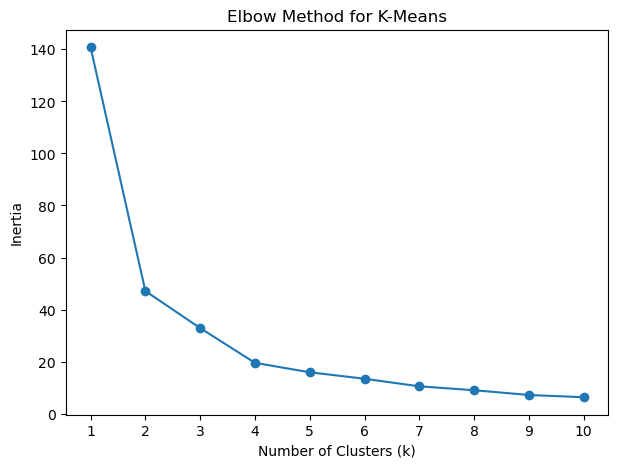

In [12]:
# visualization
plt.figure(figsize=(7, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.show()

##### K-Means Elbow Findings

The Bayesian Information Criterion (BIC) reaches its lowest value at 2 components. Therefore, a 2-component Gaussian Mixture Model is selected as the preferred GMM configuration.
The inertia decreases substantially as the number of clusters increases from 1 to 4. After approximately 4 clusters, the reduction in inertia becomes more gradual. Therefore, 4 clusters are selected for the K-Means model

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
4.2. GMM using BIC
</h4>

We are again testing 1, 2, 3, ... 10 clusters, but instead of inertia, each GMM gets a BIC score, BIC considers both how well the model fits the data and its complexity, here specifically a `lower BIC is preferred`

In [13]:
from sklearn.mixture import GaussianMixture

bic_scores = []
cluster_range = range(1, 11)

for n in cluster_range:
    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )
    
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: User

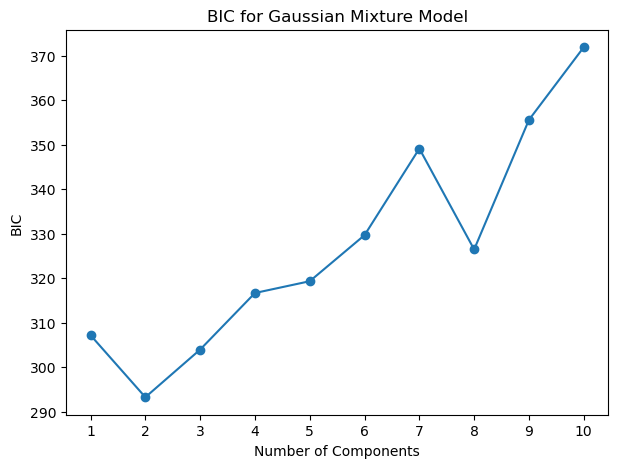

In [14]:
# visualization
plt.figure(figsize=(7, 5))

plt.plot(cluster_range, bic_scores, marker="o")

plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Model")
plt.xticks(cluster_range)
plt.show()

##### GMM BIC Findings

The Bayesian Information Criterion (BIC) reaches its lowest value at 2 components. Therefore, a 2-component Gaussian Mixture Model is selected as the preferred GMM configuration

<h3 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
5. Clustering Models
</h3>

K-Means and Gaussian Mixture Models are applied to the PCA-transformed data using the number of clusters identified by the Elbow Method and BIC respectively

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
5.1. K-Means
</h4>

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

pca_df["KMeans_Cluster"] = kmeans.fit_predict(X_pca)

c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
5.2. GMM
</h4>

In [16]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

pca_df["GMM_Cluster"] = gmm.fit_predict(X_pca)  

c:\Users\kevin\anaconda3\envs\win_c0c1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<h3 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
6. Clustering Results and Visualization
</h3>

The clustering results are visualized using the two principal components. This allows the cluster structures identified by K-Means and GMM to be compared.

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
6.1. K-Means Visualization
</h4>


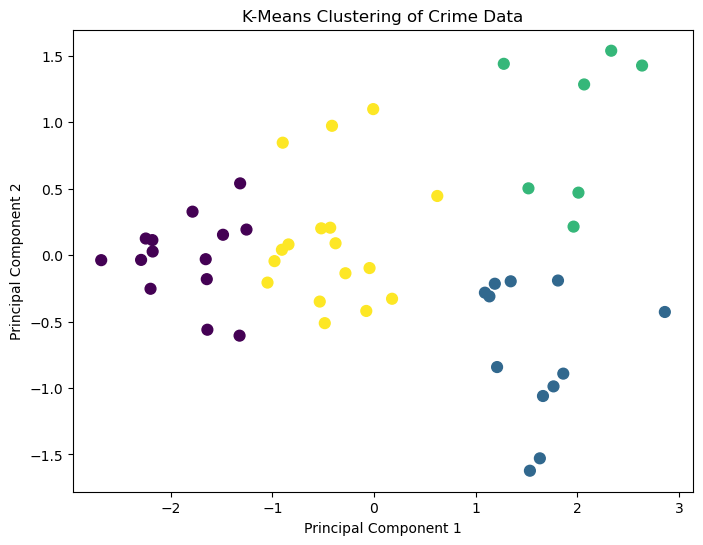

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans_Cluster"],
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Crime Data")
plt.show()

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
6.2. GMM Visualization
</h4>

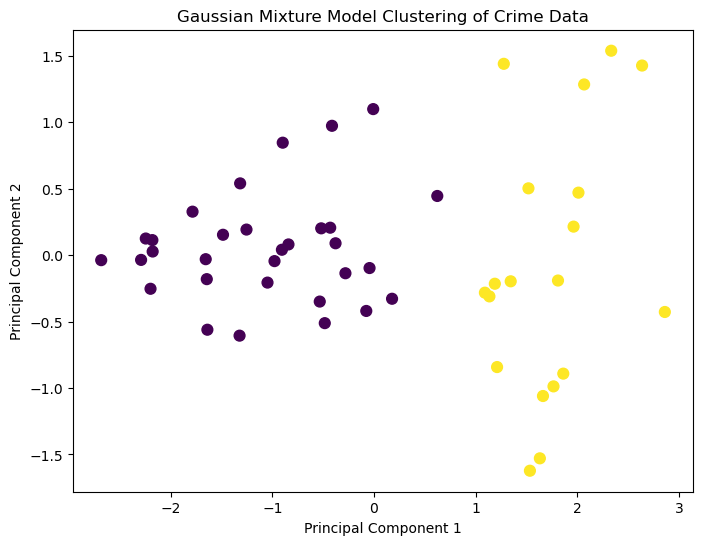

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["GMM_Cluster"],
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Gaussian Mixture Model Clustering of Crime Data")
plt.show()

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
Comparison of Clustering Results
</h4>

The K-Means model separates the states into four distinct clusters, providing a more detailed segmentation of regional crime patterns. The clusters are mainly separated along the first principal component, with further separation occurring along the second component

The GMM produces two broader clusters, consistent with the two-component solution selected using BIC. Compared with K-Means, GMM provides a simpler grouping of the states and models cluster membership in a probabilistic way

Overall, the two methods reveal different levels of structure in the same crime data: K-Means identifies four more granular groups, while GMM identifies two broader groups

<h4 style= "color: #9CA3AF; text-align: left; font-weight: bold;">
Conclusion
</h4>

The analysis identified patterns in crime statistics across U.S. states using feature selection, PCA, K-Means, and Gaussian Mixture Models.

`Murder`, `Assault`, and `Rape` were selected as the three clustering features and standardized before PCA was applied. The first two principal components retained approximately 93.89% of the original variance.

The Elbow Method suggested four clusters for K-Means, while the lowest BIC supported two components for GMM. The resulting visualizations show that K-Means provides a more detailed four-group segmentation, whereas GMM represents the data using two broader probabilistic groups.